## $R^2$ score
- What is this metric
- How is it computed
- Drawback
- Fix

Below are couple of code blocks which generate a sample 1-Dimensional data for sample input and output.
- First we plot the residuals against the mean of the sample data
- Then we plot the simple harcoded regression line on the data
- And compute the residuals against the regression line

In [1]:
import numpy as np
import matplotlib.pyplot as plt

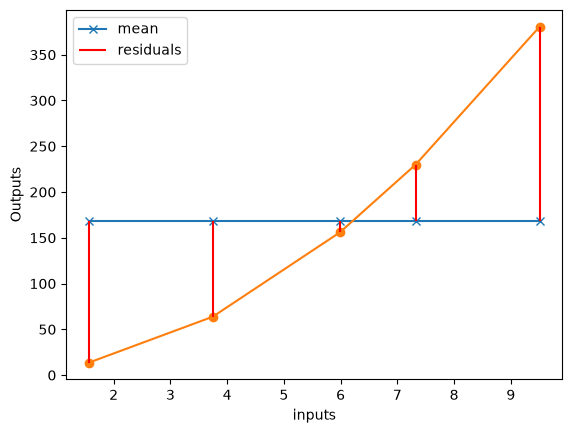

In [3]:
np.random.seed(42)
def generate_1d_data(l: int):
    x = np.random.rand(l)*10
    y = 2*x + 4*(x**2) + [np.random.rand(1).tolist()[0] for i in range(l)]
    return x, y
x, y = generate_1d_data(5)
idx = np.argsort(x)
output_avg = y.mean()
plt.plot(x[idx], np.full(len(x), output_avg), marker='x', label='mean')
plt.plot(x[idx], y[idx], marker='o')
plt.vlines(
    x[idx], 
    [min(output_avg, y[i]) for i in idx],
    [max(output_avg, y[i]) for i in idx],
    colors='red',
    label='residuals'
)

plt.xlabel("inputs")
plt.ylabel("Outputs")
plt.legend()
plt.show()

In [4]:
residuals_mean = [(y[i] - output_avg) for i in idx]
residuals_variance = sum([r**2 for r in residuals_mean]) / len(residuals_mean)
residuals_variance.round(3)

np.float64(16777.555)

## The variance of the mean model computed as
$$
\begin{aligned}
Var_{mean} &= \frac{1}{n}\sum_{1}^{n}(y_{mean} - y_i)^2 \\
\implies Var_{mean} &= 16777.555
\end{aligned}
$$

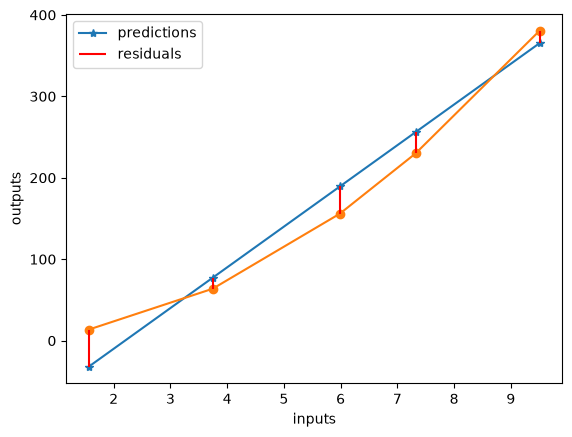

In [5]:
y_pred = 50*x - 110
plt.plot(x[idx], y_pred[idx], marker='*', label="predictions")
plt.plot(x[idx], y[idx], marker='o')
plt.vlines(
    x[idx], 
    [min(y_pred[i], y[i]) for i in idx],
    [max(y_pred[i], y[i]) for i in idx],
    colors='red',
    label='residuals'
)
plt.xlabel('inputs')
plt.ylabel('outputs')
plt.legend()
plt.show()

In [6]:
residuals_pred = [(y[i] - y_pred[i]) for i in idx]
residuals_variance = sum([r**2 for r in residuals_pred]) / len(residuals_pred)
residuals_variance.round(3)

np.float64(858.148)

## The variance of the regression line model computed as
$$
\begin{aligned}
Var_{pred} &= \frac{1}{n}\sum_{1}^{n}(y_{pred} - y_i)^2 \\
\implies Var_{pred} &= 858.148
\end{aligned}
$$

### Therefore we can have a metric of how much variance is explained by the line regression model
### That will be the fraction of variance reduced
$$
\begin{aligned}
metric &= \frac{Var_{mean} - Var_{pred}}{Var_{mean}} \times 100 \\
&= \frac{16777.555 - 858.148}{16777.555} \times 100 \\
&= 94.885\% \\
&= 0.948 
\end{aligned}
$$
#### This infact is the ${R^2 score}$ metric, and this implies the fraction of variance explained by the model compared to the residual variance from using just the mean.

## Drawback to ${R^2 score}$
The standard $R^2$ is gullible metric. It blindly rewards for adding more variables to the model, even if the new variable data is garbage.Because of this, it is a dangerous measure of a model's true predictive power if used in isolation.

When we train a regression model the underlying algorithm's objective is to minimize the error (computed by for e.g. least squares) in our training dataset.
Now lets imagine we are working on a dataset and we added a completely irrelevant/useless variable to the dataset, the algorithm will find some microscopic, accidental pattern linking to that irrelevant variable to the target in our specific dataset.

Because the algorithm found that tiny accidental correlation, it assigns a small weight to that irrelevant variable.This slightly improves the model's fit on the training data, shrinking the total error.

- if the random variable helps (even accidently), the total error goes down
- If the random variable is mathematically perfectly useless (incredibly rare in real data), the algorithm will assign it a weight of zero, and the total error stays exactly the same.

Because $R^2$ is calculated based on how much the error is reduced, standard $R^2$ can only increase of stay flat. It can never decrease when a variable is added.

This flaw leads directly to **overfitting**. One might just throw dozens of variables into a model to chase a $0.99 R^2$ score. The model looks perfect on paper because it learnt the noise in the training data, but it will fail entirely when predicting real-world, unseen data.

### Fix: Adjusted $R^2$
The formula is as:
$$
\text{Adj. } R^2 = 1 - \frac{(1-R^2)(n-1)}{(n-k-1)}
$$
Where:
$$
\begin{aligned}
n &= \text{sample size} \\
k &= \text{number of independent predictors} \\
R^2 &= \text{standard R-squared}
\end{aligned}
$$

When we add a predictor that genuinely improves the model, Adjusted $R^2$ increases. When you add a predictor that contributes little, Adjusted $R^2$ decreases or stays flat. This makes it the correct metric for comparing multiple linear regressions models with different numbers of predictors.